In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import logging
import tensorflow as tf
import tensorflow_datasets as tfds
from urllib import parse
from http.server import HTTPServer, BaseHTTPRequestHandler


logger = tf.get_logger()
logger.setLevel(logging.ERROR)

dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

In [2]:
class_names = [
'Cero', 'Uno', 'Dos', 'Tres', 'Cuatro', 'Cinco', 'Seis', 'Siete',
'Ocho', 'Nueve'
]


In [3]:
num_train_examples = metadata.splits['train'].num_examples
num_test_examples = metadata.splits['test'].num_examples

In [4]:
def normalize(images, labels):
    images = tf.cast(images, tf.float32)
    images /= 255
    return images, labels

In [5]:
train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)


In [6]:
model = tf.keras.Sequential([
tf.keras.layers.Flatten(input_shape=(28,28,1)),
tf.keras.layers.Dense(64, activation=tf.nn.relu),
tf.keras.layers.Dense(64, activation=tf.nn.relu),
tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])


c:\Users\herna\anaconda3\envs\notebooks\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
BATCHSIZE = 32
train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(BATCHSIZE)
test_dataset = test_dataset.batch(BATCHSIZE)


In [9]:
model.fit(
    train_dataset, epochs=5,
    steps_per_epoch=math.ceil(num_train_examples/BATCHSIZE)
)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8614 - loss: 0.4746
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9616 - loss: 0.1293
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9711 - loss: 0.0956
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9765 - loss: 0.0763
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9825 - loss: 0.0605


In [10]:
test_loss, test_accuracy = model.evaluate(
test_dataset, steps=math.ceil(num_test_examples/32)
)
print("Resultado en las pruebas: ", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - accuracy: 0.9685 - loss: 0.1004
Resultado en las pruebas:  0.97079998254776


In [11]:
for test_images, test_labels in test_dataset.take(1):
    test_images = test_images.numpy()
    test_labels = test_labels.numpy()
    predictions = model.predict(test_images)

def plot_image(i, predictions_array, true_labels, images):
    predictions_array, true_label, img = predictions_array[i], true_labels[i], images[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[...,0], cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
        
    plt.xlabel("Prediccion: {}".format(class_names[predicted_label]), color=color)

def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#888888")
    plt.ylim([0,1])
    predicted_label = np.argmax(predictions_array)
    
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


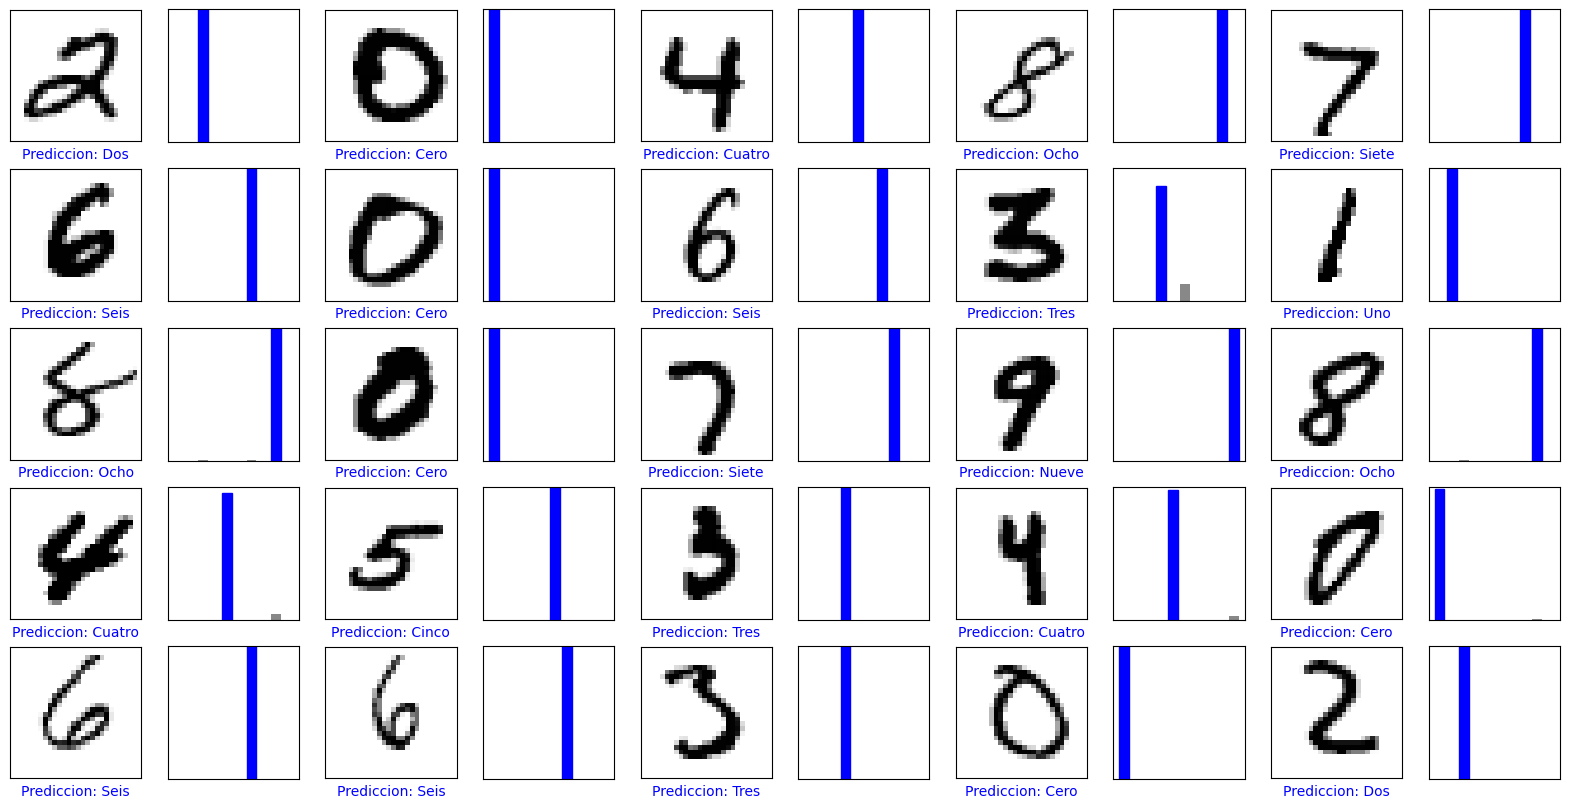

In [12]:
filas = 5
columnas = 5
num_imagenes = filas * columnas
plt.figure(figsize=(2*2*columnas, 2*filas))

for i in range(num_imagenes):
    plt.subplot(filas, 2*columnas, 2*i+1)
    plot_image(i, predictions, test_labels, test_images)
    plt.subplot(filas, 2*columnas, 2*i+2)
    plot_value_array(i, predictions, test_labels)

plt.show()

In [13]:
class SimpleHTTPRequestHandler(BaseHTTPRequestHandler):
    def do_POST(self):
        print("Peticion recibida")
        #Obtener datos de la petición y limpiar los datos
        content_length = int(self.headers['Content-Length'])
        data = self.rfile.read(content_length)
        data = data.decode().replace('pixeles=', '')
        data = parse.unquote(data)
        #Realizar transformación para dejar igual que los ejemplos que usa MNIST
        arr = np.fromstring(data, np.float32, sep=",")
        arr = arr.reshape(28,28)
        arr = np.array(arr)
        arr = arr.reshape(1,28,28,1)
        #Realizar y obtener la predicción
        prediction_values = model.predict(arr, batch_size=1)
        prediction = str(np.argmax(prediction_values))
        print("Prediccion final: " + prediction)
        #Regresar respuesta a la peticion HTTP
        self.send_response(200)
        #Evitar problemas con CORS
        self.send_header("Access-Control-Allow-Origin", "*")
        self.end_headers()
        self.wfile.write(prediction.encode())


In [ ]:
print("Iniciando el servidor...")
server = HTTPServer(('localhost', 8000), SimpleHTTPRequestHandler)
server.serve_forever()


Iniciando el servidor...
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Prediccion final: 3


127.0.0.1 - - [09/Mar/2026 18:45:20] "POST / HTTP/1.1" 200 -


Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Prediccion final: 8


127.0.0.1 - - [09/Mar/2026 18:45:23] "POST / HTTP/1.1" 200 -


Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Prediccion final: 8


...

127.0.0.1 - - [09/Mar/2026 18:46:12] "POST / HTTP/1.1" 200 -


Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Prediccion final: 6


127.0.0.1 - - [09/Mar/2026 18:46:17] "POST / HTTP/1.1" 200 -


Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Prediccion final: 9


127.0.0.1 - - [09/Mar/2026 18:46:19] "POST / HTTP/1.1" 200 -
